## MNIST Data: Handwritten Digit Classification

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

### Load MNIST Data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])


training_data = datasets.MNIST(
    root="data_MNIST",
    download=True,
    train=True, 
    transform=transform
)


test_data = datasets.MNIST(
    root="data_MNIST",
    download=True,
    train=False, 
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


In [3]:
len(training_data)

60000

In [4]:
len(test_data)

10000

In [7]:
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

data_iter = iter(train_loader)
images, labels = next(data_iter)

In [13]:
labels[2]

tensor(0)

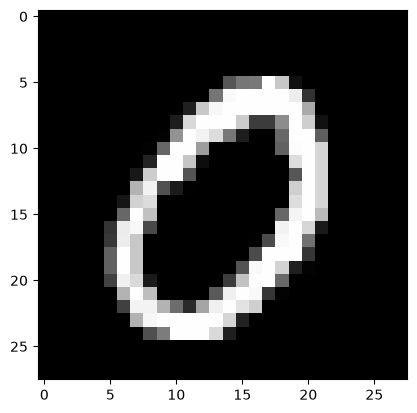

In [12]:
plt.imshow(images[2].squeeze(), cmap='gray')
plt.show()

### Define NN Class

In [14]:
class DigitsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)
            

In [15]:
model = DigitsClassifier()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

### NN Training

In [16]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()

        # Weight Update
        optimizer.step()

    print(f"Epoch [{epoch + 1} / {epochs}], Loss: {running_loss / len(train_loader): .2f}") 

Epoch [1 / 5], Loss:  0.40
Epoch [2 / 5], Loss:  0.20
Epoch [3 / 5], Loss:  0.14
Epoch [4 / 5], Loss:  0.11
Epoch [5 / 5], Loss:  0.09


### NN Evaluation

In [28]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)
print(f"Accuracy on Test Set: {100 * correct / total:.2f}%")

Accuracy on Test Set: 96.79%
